In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# load your dataset
df = pd.read_csv("/content/Titanic Dataset.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
print("Shape:", df.shape)

Shape: (418, 12)


In [ ]:
print("Columns:", df.columns.tolist())

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


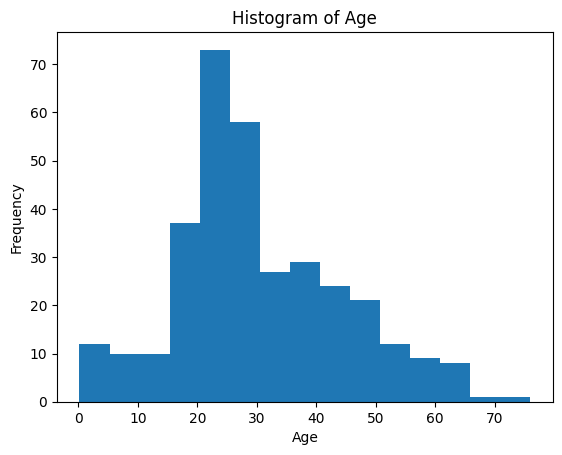

In [ ]:
plt.figure()
plt.hist(df["Age"], bins=15)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

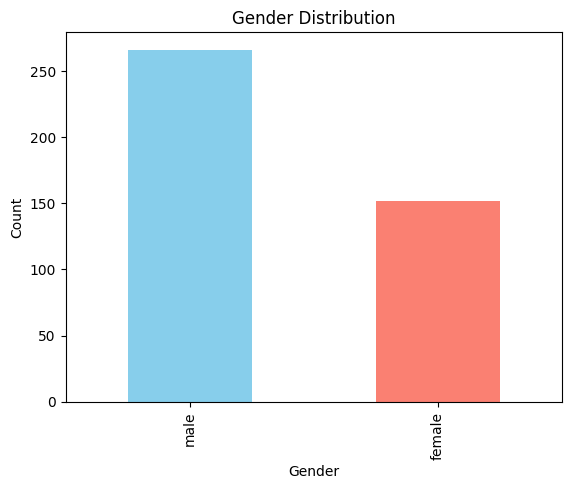

In [ ]:
gender_counts = df["Gender"].value_counts()
plt.figure()
gender_counts.plot(kind="bar", color=["skyblue","salmon"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

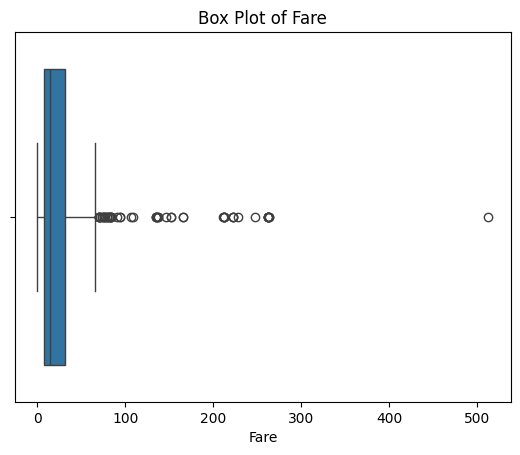

In [ ]:
plt.figure()
sns.boxplot(x=df["Fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [ ]:
# Calculate quartiles for Fare
Q1 = df["Fare"].quantile(0.25)
Q2 = df["Fare"].quantile(0.50)   # Median
Q3 = df["Fare"].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
print("Q1 (25th percentile):", Q1)
print("Median (Q2):", Q2)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)

Q1 (25th percentile): 7.8958
Median (Q2): 14.4542
Q3 (75th percentile): 31.5
IQR: 23.6042


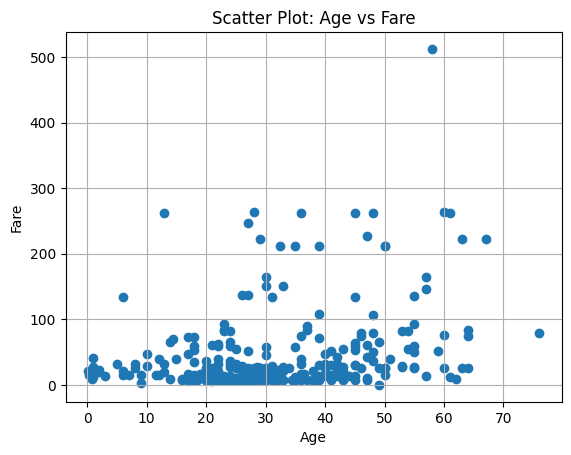

In [ ]:
plt.figure()
plt.scatter(df["Age"], df["Fare"])
plt.title("Scatter Plot: Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.grid(True)
plt.show()

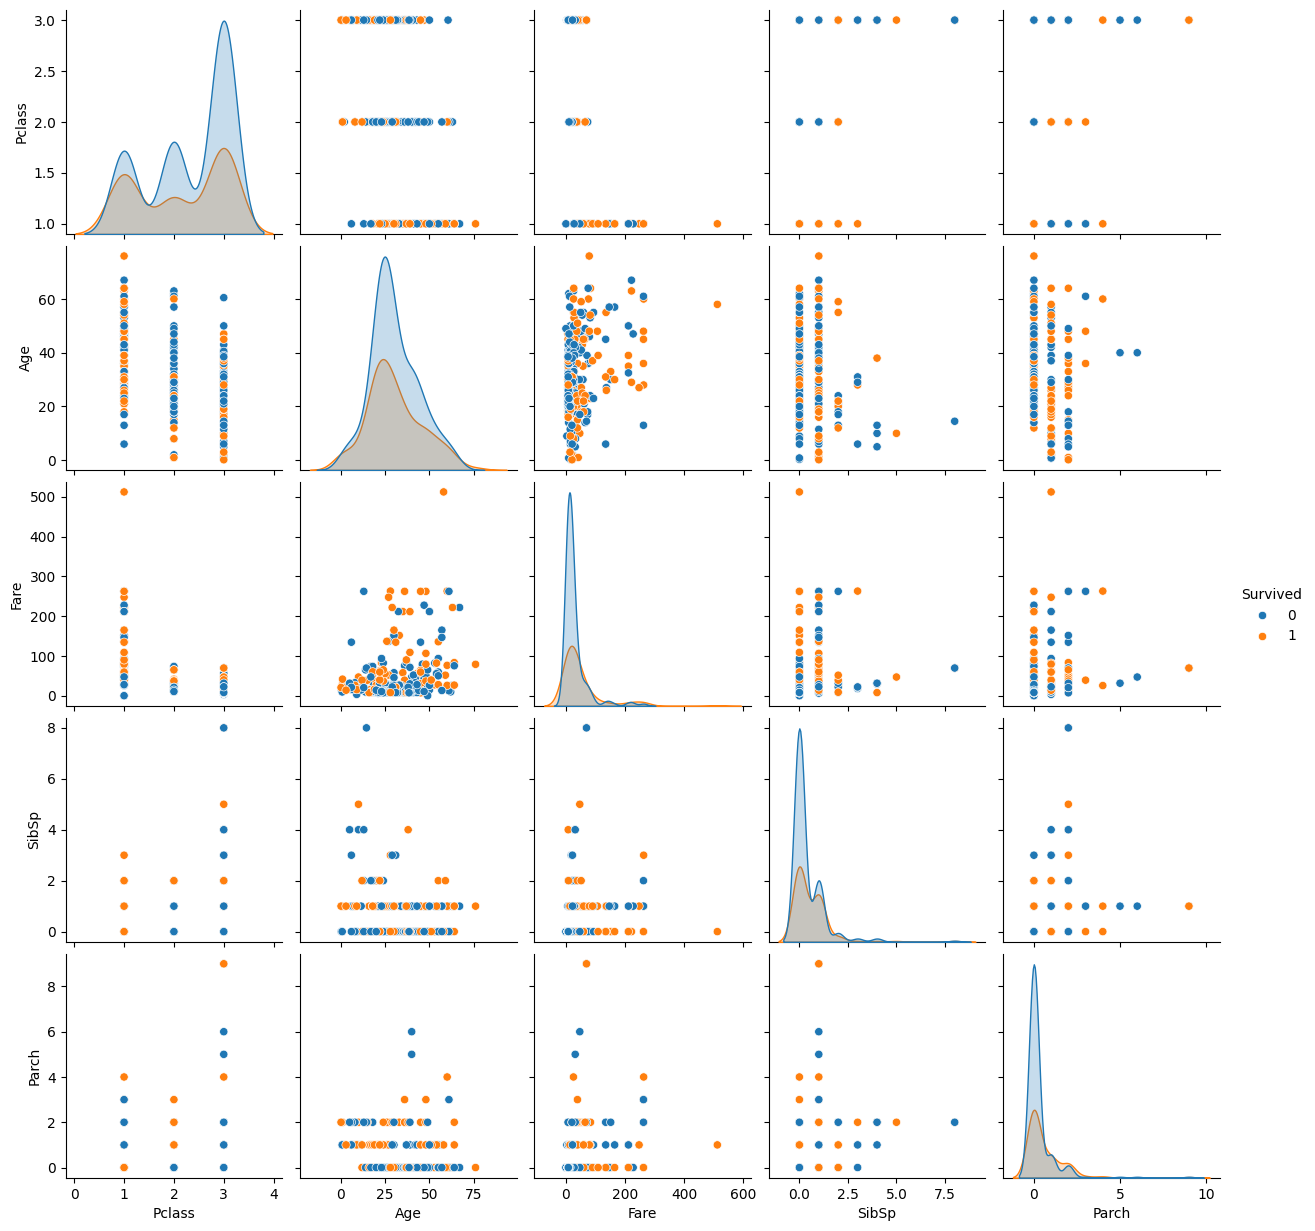

In [ ]:
selected_cols = ["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"]
sns.pairplot(df[selected_cols], hue="Survived")
plt.show()

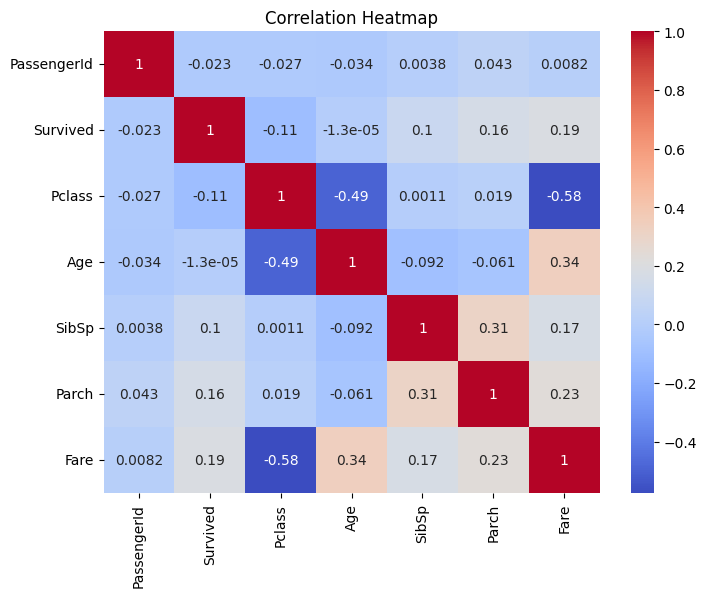

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
sorted_corr = corr.unstack().sort_values(ascending=False)
sorted_corr = sorted_corr[sorted_corr != 1]
print(sorted_corr.head(15))

Fare         Age         0.337932
Age          Fare        0.337932
Parch        SibSp       0.306895
SibSp        Parch       0.306895
Fare         Parch       0.230046
Parch        Fare        0.230046
Survived     Fare        0.191514
Fare         Survived    0.191514
SibSp        Fare        0.171539
Fare         SibSp       0.171539
Survived     Parch       0.159120
Parch        Survived    0.159120
SibSp        Survived    0.099943
Survived     SibSp       0.099943
PassengerId  Parch       0.043080
dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler
features = ["Age", "Fare", "SibSp", "Parch"]
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])
df_scaled.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,0.452723,0.000,0.000000,330911,0.015282,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,0.617566,0.125,0.000000,363272,0.013663,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,0.815377,0.000,0.000000,240276,0.018909,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,0.353818,0.000,0.000000,315154,0.016908,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,0.287881,0.125,0.111111,3101298,0.023984,NaN,S


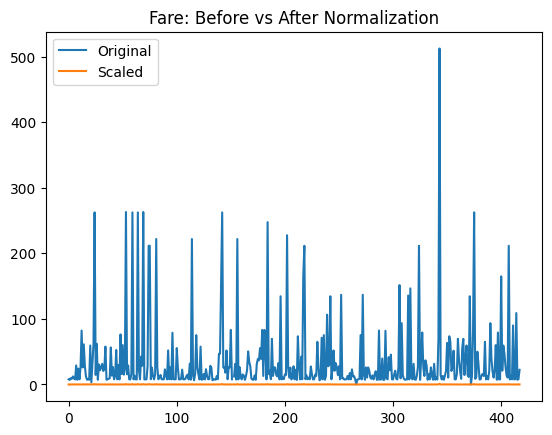

In [ ]:
plt.plot(df["Fare"], label="Original")
plt.plot(df_scaled["Fare"], label="Scaled")
plt.title("Fare: Before vs After Normalization")
plt.legend()
plt.show()

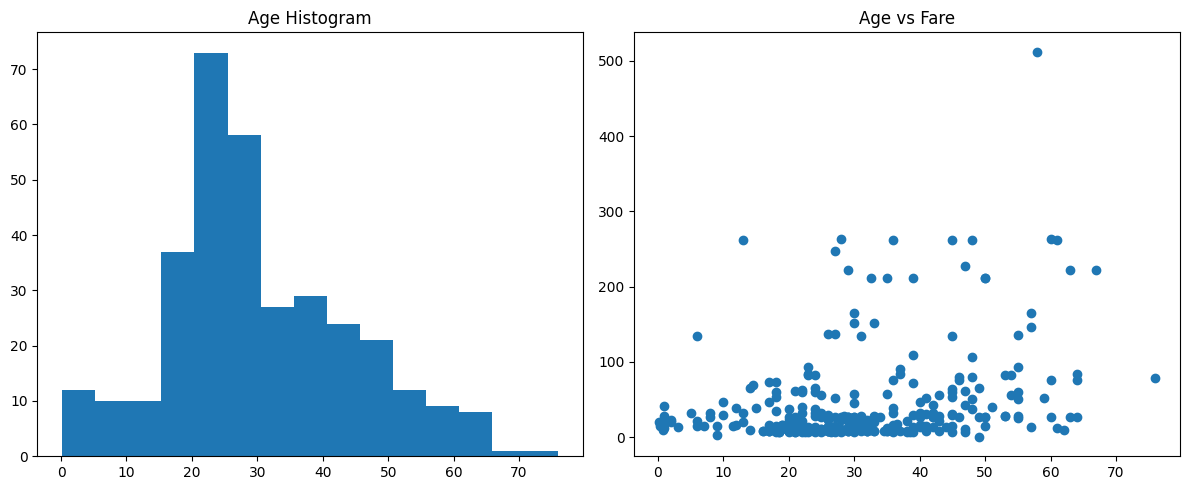

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(df["Age"].dropna(), bins=15)
ax[0].set_title("Age Histogram")

ax[1].scatter(df["Age"], df["Fare"])
ax[1].set_title("Age vs Fare")

plt.tight_layout()
plt.show()

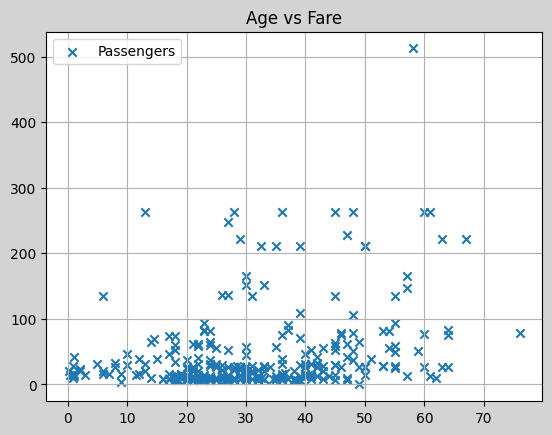

In [ ]:
plt.figure(facecolor="lightgray")

plt.scatter(df["Age"], df["Fare"], marker="x", label="Passengers")

plt.title("Age vs Fare")
plt.legend()
plt.grid(True)

plt.show()